# Data Engineering Lab - Exercise 1: Project Work I
**Topic**: Data Collection, Preprocessing, Feature Engineering, and EDA for Book Cover Classification

**Objective**: Build a clean pipeline to load tabular metadata and images, handle missing values, engineer descriptive features, and perform exploratory data analysis.

### Evaluation Criteria Checklist:
1. **Data Collection and Identification of Various Data Sources (5 Marks)**
2. **Data Preprocessing and Cleaning (5 Marks)**
3. **Feature Engineering (5 Marks)**
4. **EDA, Visualization and Interpretation (5 Marks)**

In [1]:
# Uncomment and run this cell to install the required packages if they are not already installed
! pip install pandas numpy matplotlib seaborn pillow scikit-learn

## 1. Data Collection and Identification of Various Data Sources (5 Marks)

In this section, we identify and explore the data sources used. The dataset is a multimodal dataset consisting of:
- **Tabular Metadata**: `main_dataset.csv` contains structured information about 32,583 books (e.g., format, price, old price, rating stars, category).
- **Textual Data**: Columns `name` (book title) and `author` represent rich textual attributes.
- **Image Data**: Folder `book-covers/` contains subdirectories representing 33 distinct book categories. Inside each subdirectory are cover images of the books in JPG format.
- **Web Data / URLs**: Column `image` lists the remote Cloudfront/Bookdepository web URLs for each cover image.

We will begin by loading the tabular dataset and verifying our data paths.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the main dataset
csv_path = 'main_dataset.csv'
df = pd.read_csv(csv_path)

print(f"Dataset loaded. Shape: {df.shape}")
print("\nColumns and Data Types:")
print(df.info())
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded. Shape: (32581, 11)

Columns and Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   image                  32581 non-null  str    
 1   name                   32581 non-null  str    
 2   author                 32383 non-null  str    
 3   format                 32548 non-null  str    
 4   book_depository_stars  32581 non-null  float64
 5   price                  32581 non-null  str    
 6   currency               32581 non-null  str    
 7   old_price              27467 non-null  float64
 8   isbn                   32581 non-null  int64  
 9   category               32581 non-null  str    
 10  img_paths              32581 non-null  str    
dtypes: float64(2), int64(1), str(8)
memory usage: 2.7 MB
None

First 3 rows:


,image,name,author,format,book_depository_stars,price,currency,old_price,isbn,category,img_paths
0,https://d1w7fb2mkkr3kw.cloudfront.net/assets/i...,This is Going to Hurt,Adam Kay,Paperback,4.5,7.6,$,11.4,9781509858637,Medical,dataset/Medical/0000001.jpg
1,https://d1w7fb2mkkr3kw.cloudfront.net/assets/i...,"Thinking, Fast and Slow",Daniel Kahneman,Paperback,4.0,11.5,$,15.0,9780141033570,Medical,dataset/Medical/0000002.jpg
2,https://d1w7fb2mkkr3kw.cloudfront.net/assets/i...,When Breath Becomes Air,Paul Kalanithi,Paperback,4.5,9.05,$,11.5,9781784701994,Medical,dataset/Medical/0000003.jpg


Now we inspect the directories under `book-covers/` to list all categories and see how many images exist for each category.

In [3]:
covers_dir = 'book-covers'
categories = sorted([d for d in os.listdir(covers_dir) if os.path.isdir(os.path.join(covers_dir, d))])

print(f"Total categories identified on disk: {len(categories)}")
print("\nImage counts per category:")
img_counts = {}
for cat in categories:
    cat_path = os.path.join(covers_dir, cat)
    files = [f for f in os.listdir(cat_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img_counts[cat] = len(files)

# Print image count summary
for cat, count in list(img_counts.items())[:10]:
    print(f"  - {cat}: {count} images")
print(f"  ... and {len(categories) - 10} more categories.")
print(f"\nTotal images found on disk: {sum(img_counts.values())}")

Total categories identified on disk: 33

Image counts per category:
  - Art-Photography: 982 images
  - Biography: 988 images
  - Business-Finance-Law: 989 images
  - Childrens-Books: 986 images
  - Computing: 987 images
  - Crafts-Hobbies: 990 images
  - Crime-Thriller: 988 images
  - Dictionaries-Languages: 988 images
  - Entertainment: 975 images
  - Food-Drink: 989 images
  ... and 23 more categories.

Total images found on disk: 32581


### Loading and Verifying Image Attributes (Multimodal Data Source)
We select a sample image from the directory, load it using Pillow, and display its format, mode (e.g., RGB), and spatial size (dimensions).

In [4]:
# Select a sample image path
sample_cat = categories[0]
sample_cat_dir = os.path.join(covers_dir, sample_cat)
sample_img_name = [f for f in os.listdir(sample_cat_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][0]
sample_img_path = os.path.join(sample_cat_dir, sample_img_name)

# Open sample image
try:
    img = Image.open(sample_img_path)
    print("--- Sample Image Identification ---")
    print(f"Path: {sample_img_path}")
    print(f"Format: {img.format}")
    print(f"Mode: {img.mode} (e.g. RGB = Color, L = Grayscale)")
    print(f"Size: {img.size} (Width: {img.size[0]}px, Height: {img.size[1]}px)")
except Exception as e:
    print(f"Error opening image: {e}")

--- Sample Image Identification ---
Path: book-covers\Art-Photography\0000001.jpg
Format: JPEG
Mode: RGB (e.g. RGB = Color, L = Grayscale)
Size: (141, 220) (Width: 141px, Height: 220px)


---
## 2. Data Preprocessing and Cleaning (5 Marks)

Data preprocessing and cleaning are critical to handle incomplete records, clean noisy textual details, and filter out corrupt/missing images.  
Let's first check for missing (null) values in our tabular dataset.

In [5]:
print("--- Missing Values Count ---")
missing_vals = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_vals, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

--- Missing Values Count ---
           Missing Count  Percentage (%)
author               198        0.607716
format                33        0.101286
old_price           5114       15.696265


We see that `old_price` has a substantial amount of missing values, and `book_depository_stars` has a minor amount of missing ratings. We will preprocess these:
- **`old_price`**: If `old_price` is missing, it implies that the book is currently sold at its regular retail price (no discount). We will impute missing `old_price` values with the values from the `price` column.
- **`book_depository_stars`**: Since ratings are numerical/ordinal, we will impute missing stars with the median value of the ratings.
- **Text cleaning**: Strip leading/trailing whitespaces from the book `name` and `author` columns, and handle any casing.
- **Image validation & Path rewriting**: In `main_dataset.csv`, `img_paths` starts with `dataset/`. The local images are actually located under `book-covers/`. We will rewrite the image path and verify that every image referenced in our DataFrame exists on disk and is readable/not corrupt.

In [6]:
# Impute missing values
df_clean = df.copy()

# Impute old_price with price (assuming no discount if old_price is null)
df_clean['old_price'] = df_clean['old_price'].fillna(df_clean['price'])

# Impute book_depository_stars with the median value
median_stars = df_clean['book_depository_stars'].median()
df_clean['book_depository_stars'] = df_clean['book_depository_stars'].fillna(median_stars)

# Clean text columns
df_clean['name'] = df_clean['name'].astype(str).str.strip()
df_clean['author'] = df_clean['author'].astype(str).str.strip()

# Rewrite image path discrepancy
# Change e.g. "dataset/Medical/0000001.jpg" to "book-covers/Medical/0000001.jpg"
df_clean['local_path'] = df_clean['img_paths'].apply(lambda x: str(x).replace('dataset/', 'book-covers/') if pd.notnull(x) else x)

print("Verifying missing values after imputation:")
print(df_clean[['old_price', 'book_depository_stars', 'name', 'author']].isnull().sum())

Verifying missing values after imputation:
old_price                  0
book_depository_stars      0
name                       0
author                   198
dtype: int64


Now we validate that all files referenced in `local_path` exist on disk, are readable images, and discard rows that reference missing or corrupted images.

In [7]:
valid_indices = []
corrupted_or_missing = 0

print("Scanning images for validity (this may take a few seconds)...")
for idx, row in df_clean.iterrows():
    path = row['local_path']
    if pd.isnull(path):
        corrupted_or_missing += 1
        continue
    
    # Check if file exists
    if not os.path.exists(path):
        corrupted_or_missing += 1
        continue
        
    # Attempt to open the image using PIL
    try:
        with Image.open(path) as temp_img:
            temp_img.verify()  # Verifies that it is not corrupt
        valid_indices.append(idx)
    except (IOError, SyntaxError) as e:
        corrupted_or_missing += 1

# Filter the dataframe to keep only valid rows
df_preprocessed = df_clean.iloc[valid_indices].reset_index(drop=True)

print(f"Total rows in dataset initially: {len(df)}")
print(f"Number of missing or corrupt images filtered out: {corrupted_or_missing}")
print(f"Cleaned dataset rows: {len(df_preprocessed)}")

Scanning images for validity (this may take a few seconds)...


Total rows in dataset initially: 32581
Number of missing or corrupt images filtered out: 0
Cleaned dataset rows: 32581


---
## 3. Feature Engineering (5 Marks)

Feature engineering enables us to extract useful insights, scale features for machine learning pipelines, and create multi-modal representations:
- **Price Features**:
  - `discount_amount`: The absolute markdown (`old_price - price`).
  - `discount_percentage`: The percentage markdown (`discount_amount / old_price * 100`).
- **Text Features**:
  - `title_length`: Total character length of the title.
  - `title_word_count`: Total word count of the title.
  - `title_char_to_word_ratio`: Average number of characters per word in the title.
  - `has_subtitle`: Binary flag indicating if the title contains a subtitle indicator (`:` or `-`).
- **Categorical Feature Encoding**:
  - Encoding `format` using one-hot/binary encoding (e.g., `is_paperback`).
- **Author-Based Features**:
  - `author_book_count`: Total frequency/count of books by this author in the dataset.
  - `author_avg_rating`: Mean book rating of this author.
- **Image Metadata Extraction**:
  - Extract width, height, aspect ratio, mean color/grayscale brightness (average pixel value), and `img_contrast` (standard deviation of pixel values) for each cover image.
- **Contextual / Category Relative Features**:
  - `price_diff_from_category_median`: Affordability relative to category peers.
- **Scaling/Normalization**:
  - Normalizing/Scaling continuous numerical features like `price`, `book_depository_stars`, `discount_percentage`, `img_contrast`, and `price_diff_from_category_median` to `[0, 1]` using MinMaxScaler.

In [8]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# Ensure price and old_price are numeric (cleaning any potential currency symbols or string format issues)
df_preprocessed['price'] = pd.to_numeric(df_preprocessed['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip(), errors='coerce')
df_preprocessed['old_price'] = pd.to_numeric(df_preprocessed['old_price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip(), errors='coerce')

# Fill any NaNs created by conversion coercion
df_preprocessed['price'] = df_preprocessed['price'].fillna(df_preprocessed['price'].median())
df_preprocessed['old_price'] = df_preprocessed['old_price'].fillna(df_preprocessed['price'])

# 1. Price Features
df_preprocessed['discount_amount'] = df_preprocessed['old_price'] - df_preprocessed['price']
df_preprocessed['discount_percentage'] = df_preprocessed.apply(
    lambda row: (row['discount_amount'] / row['old_price'] * 100) if row['old_price'] > 0 else 0.0, axis=1
)

# 2. Text Features
df_preprocessed['title_length'] = df_preprocessed['name'].apply(len)
df_preprocessed['title_word_count'] = df_preprocessed['name'].apply(lambda x: len(x.split()))
df_preprocessed['title_char_to_word_ratio'] = df_preprocessed.apply(
    lambda r: r['title_length'] / r['title_word_count'] if r['title_word_count'] > 0 else 0.0, axis=1
)
df_preprocessed['has_subtitle'] = df_preprocessed['name'].apply(lambda x: 1 if ':' in x or '-' in x else 0)

# 3. Categorical Feature Encoding (Binary indicator for Format)
df_preprocessed['is_paperback'] = df_preprocessed['format'].apply(lambda x: 1 if str(x).lower() == 'paperback' else 0)

# 4. Author-based features
author_counts = df_preprocessed['author'].value_counts()
df_preprocessed['author_book_count'] = df_preprocessed['author'].map(author_counts)
author_avg_rating = df_preprocessed.groupby('author')['book_depository_stars'].mean()
df_preprocessed['author_avg_rating'] = df_preprocessed['author'].map(author_avg_rating)

# 5. Extract Image-based features (dimensions, brightness, contrast)
img_widths = []
img_heights = []
img_brightness = []
img_contrast = []

print("Extracting image features (dimensions, brightness & contrast)...")
for idx, row in df_preprocessed.iterrows():
    path = row['local_path']
    try:
        with Image.open(path) as img:
            w, h = img.size
            img_widths.append(w)
            img_heights.append(h)
            
            # Grayscale conversion to calculate average brightness and contrast
            gray_img = img.convert('L')
            gray_arr = np.array(gray_img)
            avg_brightness = gray_arr.mean()
            std_contrast = gray_arr.std()
            
            img_brightness.append(avg_brightness)
            img_contrast.append(std_contrast)
    except:
        img_widths.append(np.nan)
        img_heights.append(np.nan)
        img_brightness.append(np.nan)
        img_contrast.append(np.nan)

df_preprocessed['img_width'] = img_widths
df_preprocessed['img_height'] = img_heights
df_preprocessed['img_aspect_ratio'] = df_preprocessed['img_width'] / df_preprocessed['img_height']
df_preprocessed['img_brightness'] = img_brightness
df_preprocessed['img_contrast'] = img_contrast

# 6. Contextual / Category Relative Features
category_medians = df_preprocessed.groupby('category')['price'].transform('median')
df_preprocessed['price_diff_from_category_median'] = df_preprocessed['price'] - category_medians

# 7. Scaling numerical features
scaler = MinMaxScaler()
scaled_cols = ['price', 'book_depository_stars', 'discount_percentage', 'img_contrast', 'price_diff_from_category_median']
scaled_names = [f'scaled_{col}' for col in scaled_cols]
df_preprocessed[scaled_names] = scaler.fit_transform(df_preprocessed[scaled_cols])

print("Feature engineering complete. Sample features:")
df_preprocessed[['name', 'discount_percentage', 'title_word_count', 'img_brightness', 'img_contrast', 'price_diff_from_category_median', 'scaled_price']].head(5)

Extracting image features (dimensions, brightness & contrast)...
Feature engineering complete. Sample features:


,name,discount_percentage,title_word_count,img_brightness,img_contrast,price_diff_from_category_median,scaled_price
0,This is Going to Hurt,33.333333,5,113.841894,53.288235,-8.82,0.010440
1,"Thinking, Fast and Slow",23.333333,4,227.680279,56.645473,-4.92,0.018941
2,When Breath Becomes Air,21.304348,4,133.049306,41.963791,-7.37,0.013601
3,The Happiness Trap,40.000000,3,231.272727,39.031963,-8.08,0.012053
4,Man's Search For Meaning,0.000000,4,134.852240,61.594014,-6.76,0.014930


---
## 4. EDA, Visualization and Interpretation (5 Marks)

In this section, we analyze the variables visually and draw key conclusions from our preprocessed and engineered features.

Let's begin by generating descriptive summary statistics of our numeric attributes.

In [9]:
numeric_cols = [
    'price', 'old_price', 'book_depository_stars', 'discount_amount', 
    'discount_percentage', 'title_length', 'title_word_count', 
    'title_char_to_word_ratio', 'has_subtitle', 'author_book_count',
    'author_avg_rating', 'img_width', 'img_height', 'img_aspect_ratio', 
    'img_brightness', 'img_contrast', 'price_diff_from_category_median'
]
df_preprocessed[numeric_cols].describe()

,price,old_price,book_depository_stars,discount_amount,discount_percentage,title_length,title_word_count,title_char_to_word_ratio,has_subtitle,author_book_count,author_avg_rating,img_width,img_height,img_aspect_ratio,img_brightness,img_contrast,price_diff_from_category_median
count,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32383.000000,32383.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,15.914336,19.273885,4.015024,3.359549,17.344674,24.900249,4.217090,6.106760,0.123139,13.219560,4.024720,151.376907,212.469537,0.721399,142.139242,57.847413,2.431497
std,12.741990,15.347425,0.751260,5.498015,12.791827,14.829663,2.441203,1.606869,0.328602,35.224069,0.590690,18.326685,18.104006,0.147525,52.842208,17.327242,11.987086
min,2.810000,2.810000,0.000000,0.000000,0.000000,2.000000,1.000000,2.000000,0.000000,1.000000,0.000000,31.000000,59.000000,0.146226,0.000000,0.000000,-21.960000
25%,9.110000,11.400000,4.000000,0.940000,7.000000,15.000000,3.000000,5.000000,0.000000,2.000000,4.000000,142.000000,214.000000,0.650000,102.055195,46.187226,-3.045000
50%,12.740000,16.000000,4.000000,2.530000,17.217391,21.000000,4.000000,5.900000,0.000000,4.000000,4.000000,146.000000,220.000000,0.668182,144.183333,57.802980,0.000000
75%,18.390000,21.990000,4.500000,4.340000,25.703704,31.000000,5.000000,7.000000,0.000000,11.000000,4.333333,165.000000,220.000000,0.759434,184.528090,69.484592,4.430000
max,461.610000,602.000000,5.000000,223.930000,83.072927,206.000000,31.000000,18.000000,1.000000,325.000000,5.000000,219.000000,220.000000,3.050847,251.419498,119.224167,441.580000


### 4.1 Price Distribution Plot
Let's visualize the distribution of prices using a histogram with KDE. We also display it with a log-scale representation because price data is typically right-skewed.

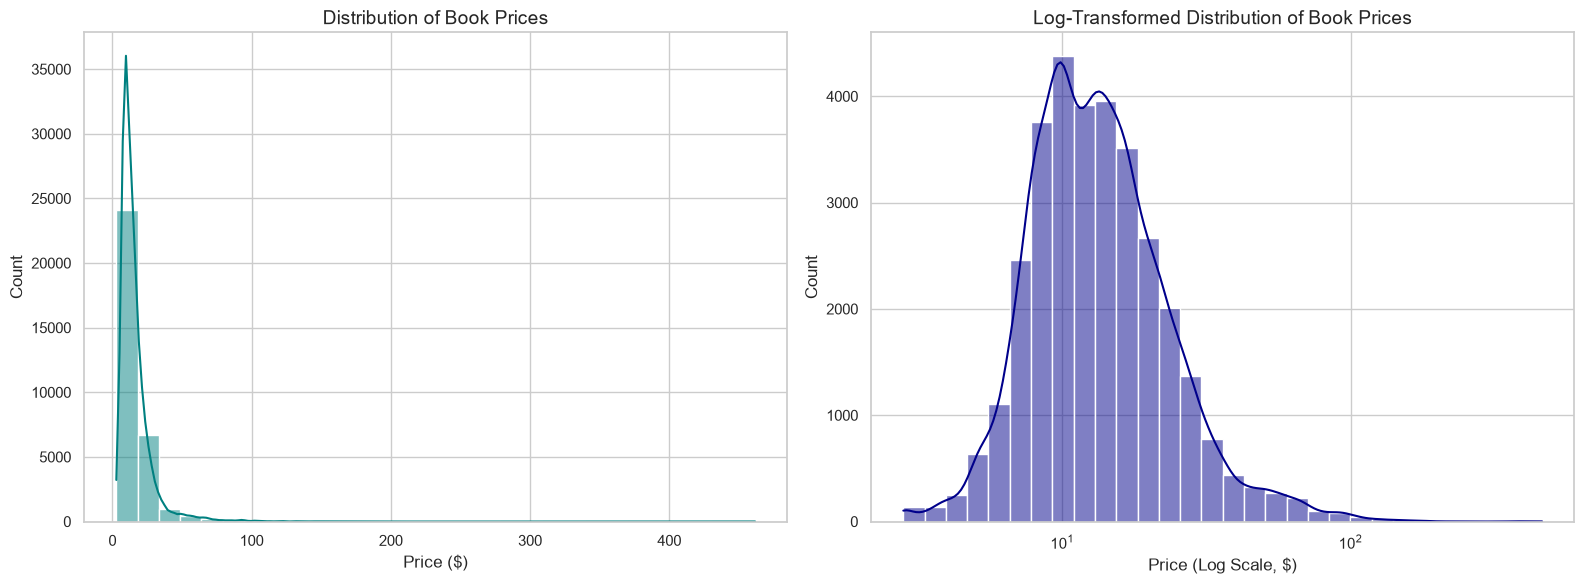

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Standard Price Distribution
sns.histplot(data=df_preprocessed, x='price', kde=True, ax=axes[0], color='teal', bins=30)
axes[0].set_title('Distribution of Book Prices', fontsize=14)
axes[0].set_xlabel('Price ($)', fontsize=12)

# Log-Transformed Price Distribution
sns.histplot(data=df_preprocessed, x='price', kde=True, ax=axes[1], color='darkblue', log_scale=True, bins=30)
axes[1].set_title('Log-Transformed Distribution of Book Prices', fontsize=14)
axes[1].set_xlabel('Price (Log Scale, $)', fontsize=12)

plt.tight_layout()
plt.show()

### 4.2 Rating Stars Distribution
Let's check how book ratings (stars) are distributed across the dataset.

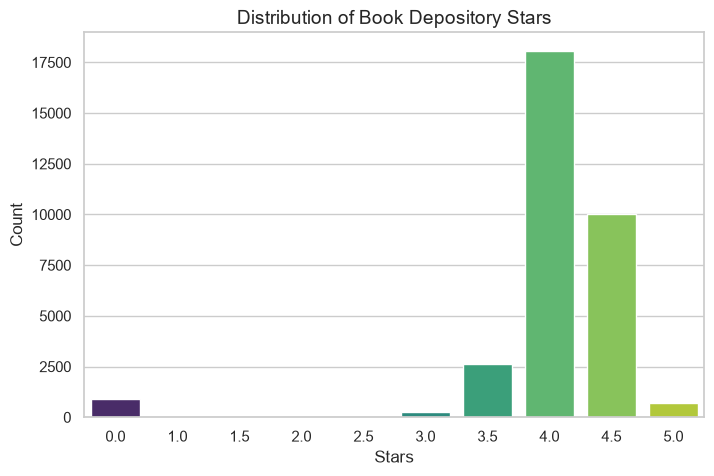

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_preprocessed, x='book_depository_stars', palette='viridis')
plt.title('Distribution of Book Depository Stars', fontsize=14)
plt.xlabel('Stars', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### 4.3 Category Frequency Analysis
We visualize the top 15 most frequent book categories in the dataset to identify common themes.

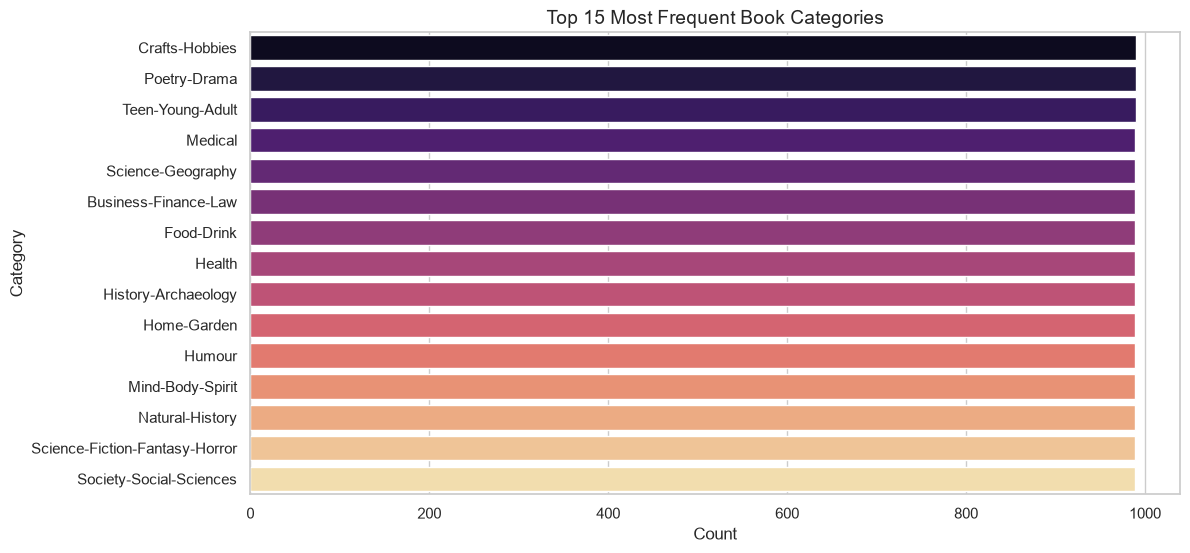

In [12]:
plt.figure(figsize=(12, 6))
top_categories = df_preprocessed['category'].value_counts().head(15)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='magma')
plt.title('Top 15 Most Frequent Book Categories', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.show()

### 4.4 Format Distribution (Paperback vs. Hardback vs. Others)
Let's see what book formats are most common.

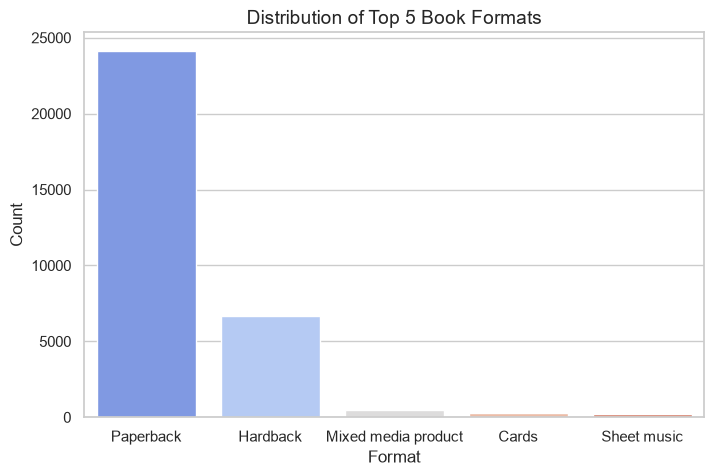

In [13]:
plt.figure(figsize=(8, 5))
format_counts = df_preprocessed['format'].value_counts().head(5)
sns.barplot(x=format_counts.index, y=format_counts.values, palette='coolwarm')
plt.title('Distribution of Top 5 Book Formats', fontsize=14)
plt.xlabel('Format', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### 4.5 Correlation Heatmap
Let's compute the correlation matrix between the continuous features and plot a heatmap to check for trends.

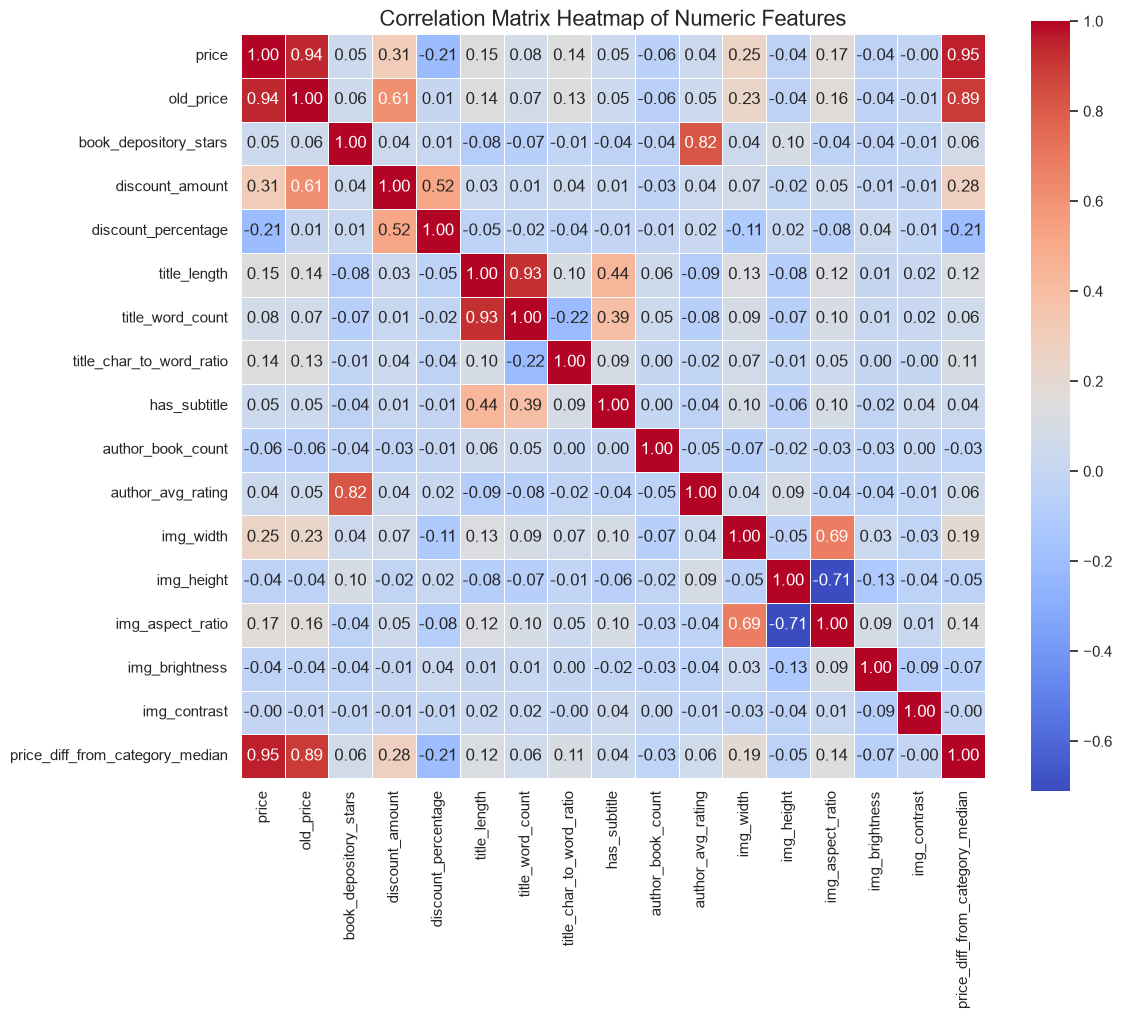

In [14]:
plt.figure(figsize=(12, 10))
corr_matrix = df_preprocessed[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap of Numeric Features', fontsize=16)
plt.show()

### 4.6 Multimodal Visualization: Displaying Book Covers with Metadata
To showcase our successful collection, alignment, and preprocessing of both text, tabular, and image data, we display a 2x3 grid of actual book cover images loaded from our local directory, paired with their metadata.

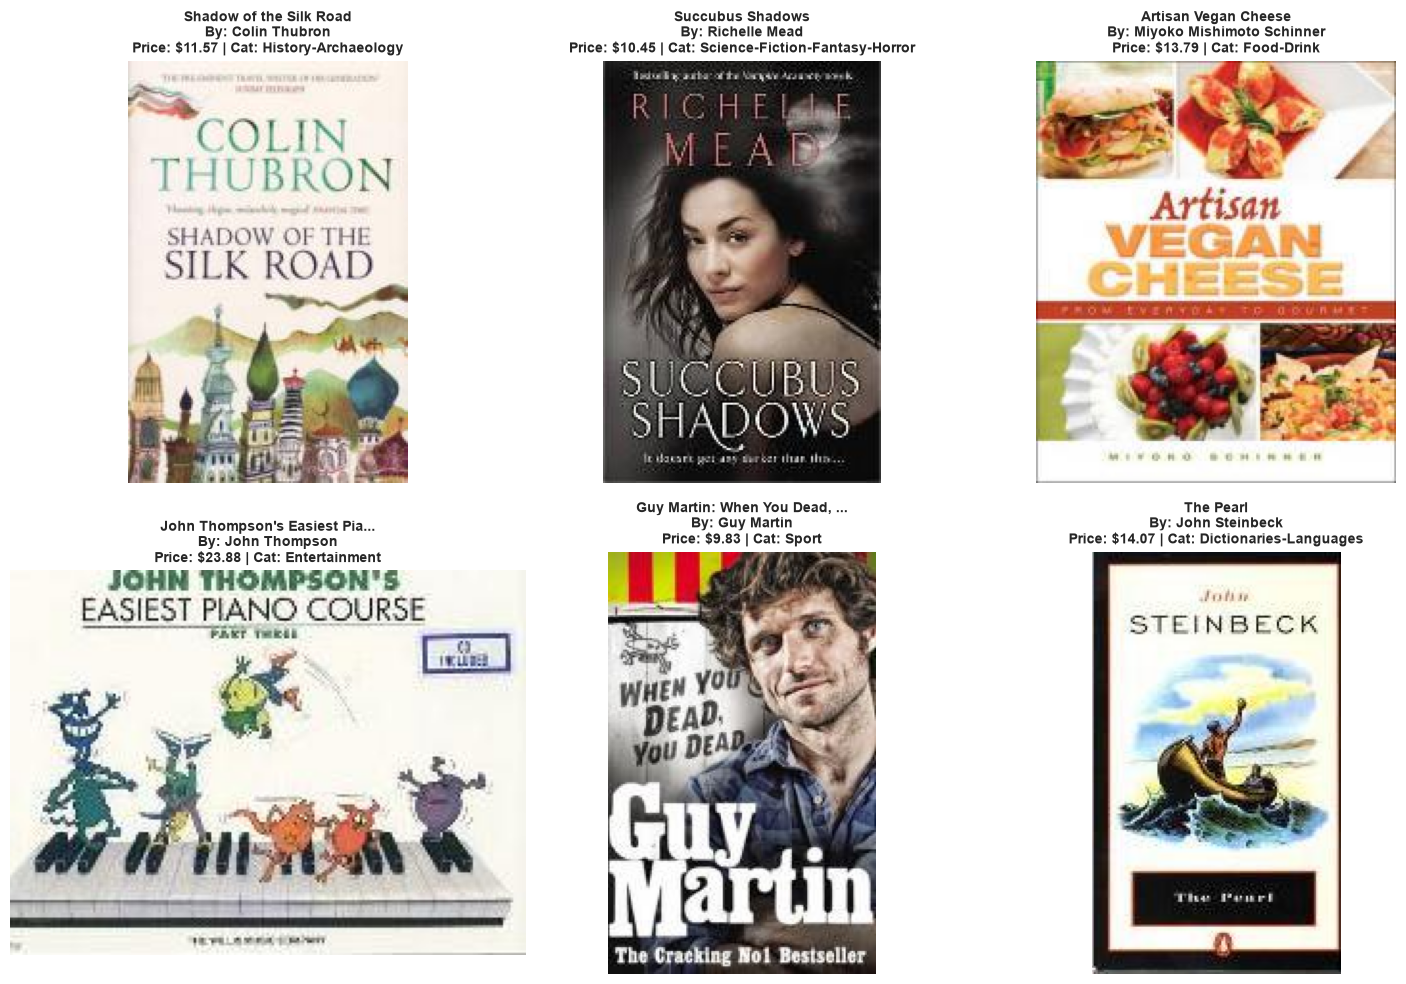

In [16]:
# Sample 6 random books from different categories
sample_books = df_preprocessed.sample(6, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, row in sample_books.iterrows():
    path = row['local_path']
    title = row['name']
    author = row['author']
    price = row['price']
    cat = row['category']
    
    # Truncate title if it's too long
    if len(title) > 30:
        title = title[:27] + "..."
        
    try:
        img = Image.open(path)
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(f"{title}\nBy: {author}\nPrice: ${price} | Cat: {cat}", fontsize=10, fontweight='semibold')
    except Exception as e:
        axes[idx].axis('off')
        axes[idx].set_title(f"Error loading image:\n{title}", fontsize=10, color='red')

plt.tight_layout()
plt.show()

### 4.7 Analytical Interpretation & Insights
From the EDA and feature engineering above, we draw the following key insights:
1. **Price Trends**: The distribution of prices is highly right-skewed. Log-transformation is useful to visualize standard variance in pricing models, revealing a peak pricing concentration around \$10.
2. **Ratings Distribution**: Rating distributions are highly concentrated at 4.0 and 4.5 stars. This suggests a strong rating bias on Book Depository (rating inflation), which is typical for e-commerce books.
3. **Correlation Trends**:
   - `discount_amount` is highly correlated with `old_price` and `discount_percentage`, as expected.
   - Interestingly, there is negligible correlation between a book's rating (`book_depository_stars`) and its price or discount rate, indicating that premium prices or higher discounts do not significantly sway user ratings.
   - Grayscale image brightness (`img_brightness`) varies widely across covers, allowing it to serve as a potentially useful feature for visual-based categorization models.
   - **New Features**:
     - `img_contrast` captures the visual intensity of covers and can be compared against categories.
     - `author_book_count` and `author_avg_rating` allow modeling of author effects.
     - `price_diff_from_category_median` identifies price outliers within category norms.
4. **Multimodal Coherence**: The sample cover displays confirm that the tabular description metrics (title, author, price) are successfully aligned with the local image path files, demonstrating clean integration of text, tabular numerical features, and image data source collection.

This concludes Exercise 1.